In [1]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("IMDB Dataset.csv")
print(df.shape)
print(df.columns)
df.head()

(50000, 2)
Index(['review', 'sentiment'], dtype='object')


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df['sentiment'].value_counts())
print(df['review'].unique())

review       0
sentiment    0
dtype: int64
418
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dod

In [5]:
df = df.drop_duplicates(subset='review').reset_index(drop=True)
print("Shape after removing duplicates",df.shape)

Shape after removing duplicates (49582, 2)


In [7]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text
df['clean_review'] = df['review'].apply(clean_text)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...


In [9]:
l = LabelEncoder()
df['sentiment'] = l.fit_transform(df['sentiment'])
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,0,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei s love in the time of money is a...


In [11]:
x = df['clean_review']
y = df['sentiment']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify = y)

In [13]:
tfidf = TfidfVectorizer(max_features=20000,ngram_range=(1,2),min_df = 2,max_df=0.95,sublinear_tf=True)
x_train = tfidf.fit_transform(x_train)
x_test = tfidf.transform(x_test)

In [19]:
lr_model = LogisticRegression(max_iter = 1000,random_state=42)
lr_model.fit(x_train,y_train)
lr_pred = lr_model.predict(x_test)
lr_prob = lr_model.predict_proba(x_test)[:,1]
print(accuracy_score(y_test,lr_pred))
print(classification_report(y_test,lr_pred))

0.9047090854088938
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      4940
           1       0.89      0.92      0.91      4977

    accuracy                           0.90      9917
   macro avg       0.91      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



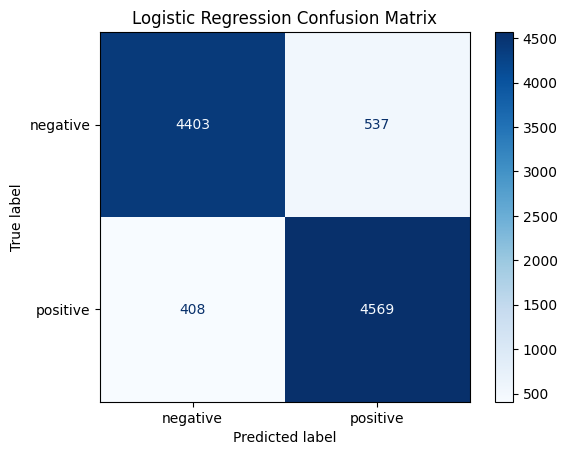

In [20]:
cm = confusion_matrix(y_test,lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=l.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [21]:
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC AUC Score:", roc_auc_score(y_test, lr_prob))

Logistic Regression Metrics:
Accuracy: 0.9047090854088938
Precision: 0.8948296122209166
Recall: 0.9180229053646776
F1 Score: 0.9062778934840822
ROC AUC Score: 0.9667845774774488


In [22]:
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)
nb_pred = nb_model.predict(x_test)
nb_prob = nb_model.predict_proba(x_test)[:,1]
print(accuracy_score(y_test,nb_pred))
print(classification_report(y_test,nb_pred))

0.8754663708782898
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4940
           1       0.87      0.88      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



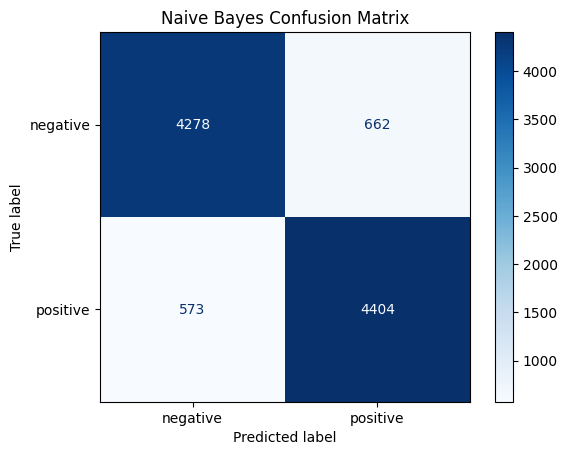

In [23]:
nb_cm = confusion_matrix(y_test,nb_pred)
nb_disp = ConfusionMatrixDisplay(confusion_matrix=nb_cm,display_labels=l.classes_)
nb_disp.plot(cmap=plt.cm.Blues)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [24]:
print("Naive Bayes Metrics:")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))
print("F1 Score:", f1_score(y_test, nb_pred))
print("ROC AUC Score:", roc_auc_score(y_test, nb_prob))

Naive Bayes Metrics:
Accuracy: 0.8754663708782898
Precision: 0.8693249111725228
Recall: 0.8848704038577456
F1 Score: 0.8770287762620731
ROC AUC Score: 0.9469234999215013


In [25]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)[:,1]
print(accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))

0.8565090249067259
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      4940
           1       0.85      0.86      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



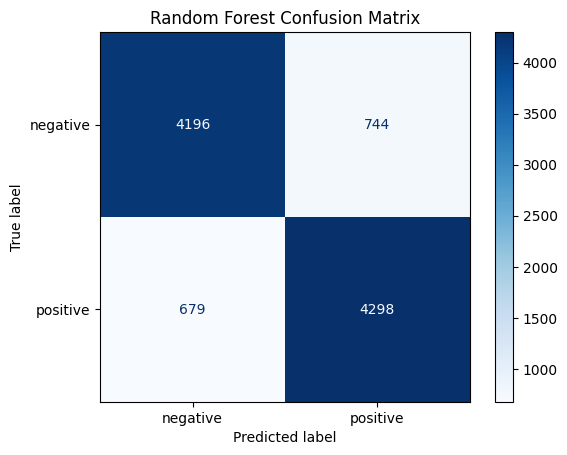

In [26]:
rf_cm = confusion_matrix(y_test,rf_pred)
rf_disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels=l.classes_)
rf_disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [27]:
print("RandomForest Metrics:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC Score:", roc_auc_score(y_test, rf_prob))

RandomForest Metrics:
Accuracy: 0.8565090249067259
Precision: 0.8524395081316938
Recall: 0.8635724331926864
F1 Score: 0.8579698572711848
ROC AUC Score: 0.9348634691239621


In [28]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_test)
xgb_prob = xgb_model.predict_proba(x_test)[:,1]
print(accuracy_score(y_test,xgb_pred))
print(classification_report(y_test,xgb_pred))

0.8517696884138348
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4940
           1       0.83      0.88      0.86      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



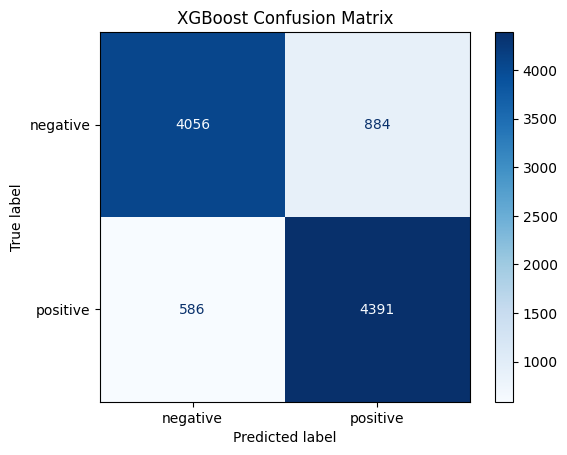

In [30]:
xgb_cm = confusion_matrix(y_test,xgb_pred)
xgb_disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm,display_labels=l.classes_)
xgb_disp.plot(cmap=plt.cm.Blues)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [29]:
print("XGBoost Metrics:")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print("ROC AUC Score:", roc_auc_score(y_test, xgb_prob))

XGBoost Metrics:
Accuracy: 0.8517696884138348
Precision: 0.8324170616113744
Recall: 0.8822583885875025
F1 Score: 0.8566133437378073
ROC AUC Score: 0.9349415814772245


In [33]:
results = {
    "Model":["Logistic Regression","Naive Bayes","Random Forest","XGBoost"],
    "Accuracy":[accuracy_score(y_test,lr_pred),accuracy_score(y_test,nb_pred),accuracy_score(y_test,rf_pred),accuracy_score(y_test,xgb_pred)],
    "Precision":[precision_score(y_test,lr_pred),precision_score(y_test,nb_pred),precision_score(y_test,rf_pred),precision_score(y_test,xgb_pred)],
    "Recall":[recall_score(y_test,lr_pred),recall_score(y_test,nb_pred),recall_score(y_test,rf_pred),recall_score(y_test,xgb_pred)],
    "F1 Score":[f1_score(y_test,lr_pred),f1_score(y_test,nb_pred),f1_score(y_test,rf_pred),f1_score(y_test,xgb_pred)],
    "ROC AUC Score":[roc_auc_score(y_test,lr_prob),roc_auc_score(y_test,nb_prob),roc_auc_score(y_test,rf_prob),roc_auc_score(y_test,xgb_prob)]
}
results_df = pd.DataFrame(results)
results_df.sort_values(by="F1 Score",ascending=False,inplace=True)
results_df.reset_index(drop=True,inplace=True)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Logistic Regression,0.904709,0.894830,0.918023,0.906278,0.966785
1,Naive Bayes,0.875466,0.869325,0.884870,0.877029,0.946923
2,Random Forest,0.856509,0.852440,0.863572,0.857970,0.934863
3,XGBoost,0.851770,0.832417,0.882258,0.856613,0.934942


In [35]:
from sklearn.model_selection import RandomizedSearchCV
lr = LogisticRegression(
    max_iter=2000,
    random_state=42
)

param_grid = {
    "C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

random_search_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lr.fit(x_train, y_train)

print("Best Parameters:", random_search_lr.best_params_)
print("Best CV F1:", random_search_lr.best_score_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Parameters: {'solver': 'lbfgs', 'class_weight': None, 'C': 5}
Best CV F1: 0.9082130285964716


In [37]:
best_lr = random_search_lr.best_estimator_

y_pred_tuned = best_lr.predict(x_test)
y_prob_tuned = best_lr.predict_proba(x_test)[:, 1]

print("Tuned Logistic Regression")
print("-" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

Tuned Logistic Regression
----------------------------------------
Accuracy : 0.9082383785418977
Precision: 0.9008476246796767
Recall   : 0.9182238296162347
F1 Score : 0.909452736318408
ROC-AUC  : 0.9694842022290391


In [43]:
def predict_sentiment(review):
    review_clean = clean_text(review)
    review_tfidf = tfidf.transform([review_clean])
    prediction = best_lr.predict(review_tfidf)[0]
    probablity = best_lr.predict_proba(review_tfidf)[0][1]
    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = probablity if prediction == 1 else (1 - probablity)

    print("Review:",review)
    print("Prediction:",sentiment)
    print(f"Confidence: {confidence:.2%}")

In [44]:
predict_sentiment(
    "This movie was absolutely fantastic. The acting was brilliant and the story was amazing."
)

Review: This movie was absolutely fantastic. The acting was brilliant and the story was amazing.
Prediction: Positive
Confidence: 99.66%


In [45]:
predict_sentiment(
    "This was one of the worst movies I have ever watched. The story was boring and the acting was terrible."
)

Review: This was one of the worst movies I have ever watched. The story was boring and the acting was terrible.
Prediction: Negative
Confidence: 99.99%


In [46]:
predict_sentiment(
    "The movie had some great moments, but the story was slow and the ending was disappointing."
)

Review: The movie had some great moments, but the story was slow and the ending was disappointing.
Prediction: Negative
Confidence: 91.69%
